# Chapter 17 Assignment — Part 2: Fraud prediction (`is_fraud`)

**Course pipeline:** CRISP-DM end-to-end using `shop.db`, from business framing through serialized model artifacts (Chapter 17 deployment pattern).

**Target:** `orders.is_fraud` (1 = fraudulent order, 0 = legitimate).

**Note on leakage:** `risk_score` in the database is correlated with fraud but is treated here as a *separate risk engine output*; we **exclude** it from features so this notebook demonstrates fraud modeling from operational checkout context (payment, device, geo, basket shape, customer history) rather than re-labeling an existing score.

## 1. Business Understanding

**Problem:** Flag online orders that are likely fraudulent *before* fulfillment so the operations team can hold, verify, or cancel high-risk orders.

**Decision use:** If `P(fraud)` exceeds a threshold, route the order to manual review or step-up verification (3DS, phone call, delayed shipment).

**Success criteria (modeling):**
- Beat the naive baseline (always predict majority class).
- Prioritize **precision** at the review threshold (review queue should be mostly true frauds) while maintaining acceptable **recall** so we do not miss most fraud.
- Report **ROC-AUC** and **PR-AUC** because fraud is **imbalanced** (~6% fraud in this sample).

**Constraints:** Features must be knowable at order placement time (no post-hoc shipment outcomes, no `risk_score` as a feature in this exercise).

## 2. Data Understanding

Load from SQLite, join core entities, and inspect distributions, missingness, and bivariate patterns (Ch. 6–8).

In [1]:
from pathlib import Path

import json
import sqlite3
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)

ROOT = Path("..").resolve()
DB_PATH = ROOT / "data" / "shop.db"
assert DB_PATH.exists(), f"Missing {DB_PATH} — place shop.db under data/"

conn = sqlite3.connect(DB_PATH)

orders = pd.read_sql("SELECT * FROM orders", conn)
customers = pd.read_sql("SELECT * FROM customers", conn)
items = pd.read_sql("SELECT * FROM order_items", conn)

conn.close()

orders.shape, customers.shape, items.shape

((5000, 17), (250, 12), (15022, 6))

In [2]:
label = "is_fraud"
vc = orders[label].value_counts(normalize=True)
print("Class balance:")
print(vc)
print("\nBaseline accuracy if always 0:", float((orders[label] == 0).mean()))

Class balance:
is_fraud
0    0.9364
1    0.0636
Name: proportion, dtype: float64

Baseline accuracy if always 0: 0.9364


In [3]:
num_cols = [
    c
    for c in orders.select_dtypes(include=[np.number]).columns
    if c not in {"order_id", "customer_id", label}
]
orders[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
promo_used,5000.0,0.252200,0.434319,0.00,0.00,0.000,1.0000,1.00
order_subtotal,5000.0,384.144678,284.124017,4.73,164.18,330.720,549.7525,1921.17
shipping_fee,5000.0,9.668290,5.126125,0.00,6.99,8.040,12.9900,28.14
tax_amount,5000.0,27.738312,21.446470,0.25,11.47,23.365,39.1525,148.13
order_total,5000.0,421.551280,305.183694,5.38,185.76,364.835,596.9400,2053.11
risk_score,5000.0,26.115940,27.433842,0.10,4.60,14.500,40.2250,100.00


In [4]:
cat_cols = ["payment_method", "device_type", "ip_country", "shipping_state"]
for c in cat_cols:
    print(f"\n=== {c} ===")
    print(orders[c].value_counts(dropna=False).head(10))


=== payment_method ===
payment_method
card      3128
paypal    1050
bank       725
crypto      97
Name: count, dtype: int64

=== device_type ===
device_type
mobile     2734
desktop    1902
tablet      364
Name: count, dtype: int64

=== ip_country ===
ip_country
US    4496
CA     218
GB     104
IN      95
NG      46
BR      41
Name: count, dtype: int64

=== shipping_state ===
shipping_state
CO    1702
OH     390
MI     367
TX     350
NC     338
AZ     296
FL     244
IL     232
WA     164
NY     149
Name: count, dtype: int64


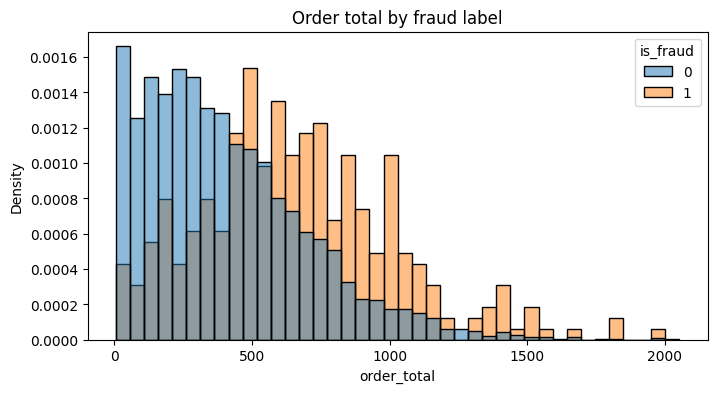

In [5]:
plt.figure(figsize=(8, 4))
sns.histplot(data=orders, x="order_total", hue=label, stat="density", common_norm=False, bins=40)
plt.title("Order total by fraud label")
plt.show()

In [6]:
oi_agg = (
    items.groupby("order_id")
    .agg(
        num_items=("quantity", "sum"),
        num_distinct_products=("product_id", "nunique"),
        avg_unit_price=("unit_price", "mean"),
        total_line_value=("line_total", "sum"),
    )
    .reset_index()
)

df = orders.merge(customers, on="customer_id", how="left", suffixes=("", "_cust"))
df = df.merge(oi_agg, on="order_id", how="left")

df["order_datetime"] = pd.to_datetime(df["order_datetime"], errors="coerce")
df["birthdate"] = pd.to_datetime(df["birthdate"], errors="coerce")
df["customer_age"] = (df["order_datetime"] - df["birthdate"]).dt.days // 365
df["order_dow"] = df["order_datetime"].dt.dayofweek
df["order_hour"] = df["order_datetime"].dt.hour
df["customer_order_count"] = df.groupby("customer_id")["order_id"].transform("count")

df.shape

(5000, 36)

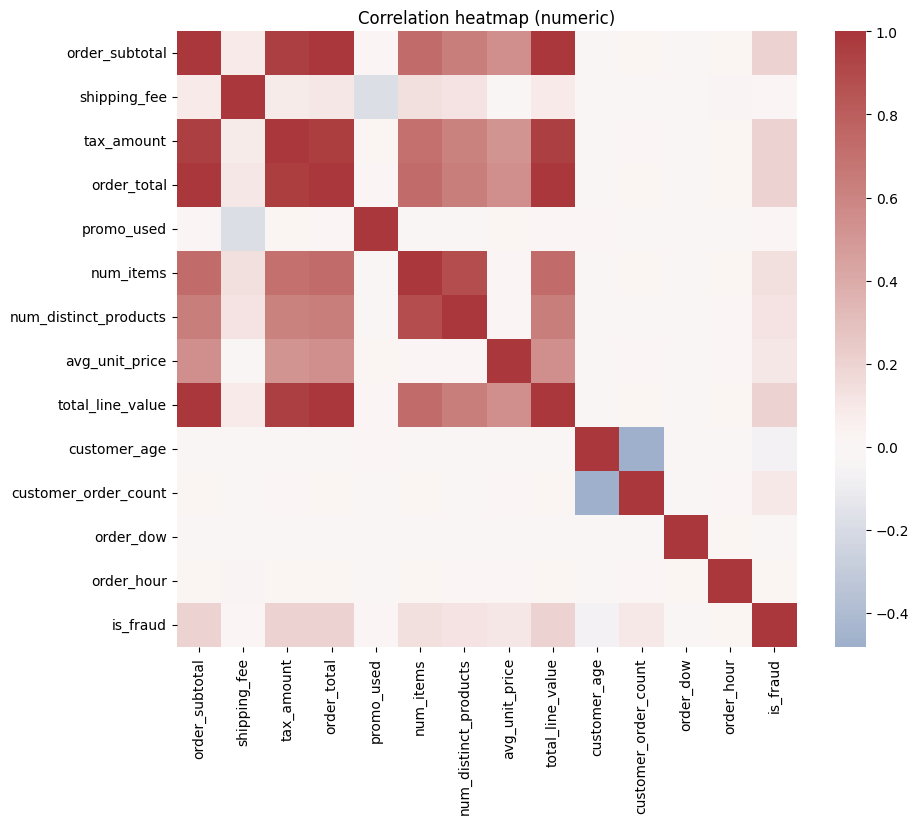

In [7]:
numeric_for_corr = [
    "order_subtotal",
    "shipping_fee",
    "tax_amount",
    "order_total",
    "promo_used",
    "num_items",
    "num_distinct_products",
    "avg_unit_price",
    "total_line_value",
    "customer_age",
    "customer_order_count",
    "order_dow",
    "order_hour",
    label,
]
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_for_corr].corr(numeric_only=True), cmap="vlag", center=0)
plt.title("Correlation heatmap (numeric)")
plt.show()

## 3. Data Preparation

- Explicit feature list (avoid accidental future columns).
- **Preprocessing inside sklearn `Pipeline`** so train/validation/test receive identical transforms (Ch. 7).
- Median imputation for numeric gaps; **one-hot** encode low-cardinality categoricals.

In [8]:
feature_numeric = [
    "order_subtotal",
    "shipping_fee",
    "tax_amount",
    "promo_used",
    "num_items",
    "num_distinct_products",
    "avg_unit_price",
    "total_line_value",
    "customer_age",
    "customer_order_count",
    "order_dow",
    "order_hour",
]

feature_categorical = [
    "payment_method",
    "device_type",
    "ip_country",
    "shipping_state",
    "gender",
    "customer_segment",
    "loyalty_tier",
]

X = df[feature_numeric + feature_categorical]
y = df[label].astype(int)

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

numeric_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "oh",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
        ),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, feature_numeric),
        ("cat", categorical_pipe, feature_categorical),
    ]
)

X_train.shape, X_test.shape

((3750, 19), (1250, 19))

## 4. Modeling (Ch. 13–14)

Compare **logistic regression** (linear baseline) with **RandomForest** and **GradientBoosting** ensembles. Use `class_weight='balanced'` on linear model to mitigate imbalance; use `scale_pos_weight` style via `sample_weight` or `class_weight` where available.

In [10]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression

models = {
    "log_reg": LogisticRegression(
        max_iter=2000, class_weight="balanced", solver="lbfgs"
    ),
    "random_forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1,
    ),
    "gbrt": GradientBoostingClassifier(random_state=42),
}

fitted = {}
for name, clf in models.items():
    pipe = Pipeline(steps=[("prep", preprocess), ("clf", clf)])
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
    print("fitted", name)

fitted log_reg
fitted random_forest
fitted gbrt


## 5. Evaluation (Ch. 15)

For fraud, **accuracy is misleading**. Report precision/recall/F1 for the positive class, ROC-AUC, and average precision (PR-AUC).

In [11]:
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
)

rows = []
for name, pipe in fitted.items():
    prob = pipe.predict_proba(X_test)[:, 1]
    pred = pipe.predict(X_test)
    rows.append(
        {
            "model": name,
            "roc_auc": roc_auc_score(y_test, prob),
            "pr_auc": average_precision_score(y_test, prob),
            "f1": f1_score(y_test, pred),
        }
    )

summary = pd.DataFrame(rows).sort_values("pr_auc", ascending=False)
summary

,model,roc_auc,pr_auc,f1
0,log_reg,0.743647,0.146014,0.217949
2,gbrt,0.726016,0.137284,0.022222
1,random_forest,0.693116,0.115506,0.000000


In [12]:
best_name = summary.iloc[0]["model"]
best = fitted[best_name]
prob = best.predict_proba(X_test)[:, 1]
pred = best.predict(X_test)
print("Best model:", best_name)
print(classification_report(y_test, pred, digits=3))

Best model: log_reg
              precision    recall  f1-score   support

           0      0.967     0.711     0.820      1171
           1      0.131     0.646     0.218        79

    accuracy                          0.707      1250
   macro avg      0.549     0.678     0.519      1250
weighted avg      0.915     0.707     0.782      1250



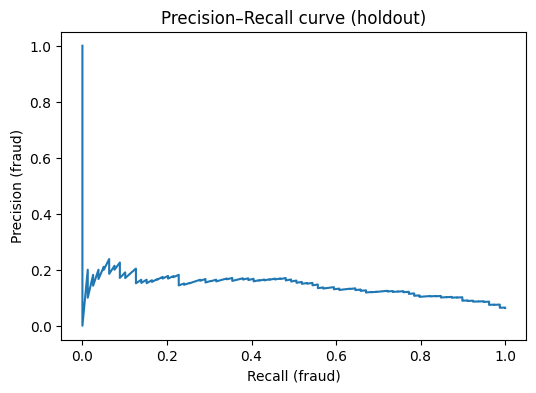

In [13]:
precision, recall, thresh = precision_recall_curve(y_test, prob)
plt.figure(figsize=(6, 4))
plt.plot(recall, precision)
plt.xlabel("Recall (fraud)")
plt.ylabel("Precision (fraud)")
plt.title("Precision–Recall curve (holdout)")
plt.show()

## 6. Feature selection & tuning (Ch. 16 + 15)

Use **SelectFromModel** with a **RandomForest** estimator (the forest is refit inside each CV fold—important because `RandomizedSearchCV` clones the pipeline). Then run a light **hyperparameter search** on the gradient boosting head (smaller grid for runtime).

In [14]:
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import RandomizedSearchCV

selector = SelectFromModel(
    RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1,
    ),
    threshold="median",
)

gbrt = GradientBoostingClassifier(random_state=42)

final_pipe = Pipeline(
    steps=[("prep", preprocess), ("select", selector), ("clf", gbrt)]
)

param_dist = {
    "clf__learning_rate": [0.03, 0.05, 0.1],
    "clf__max_depth": [2, 3, 4],
    "clf__n_estimators": [200, 400],
}

search = RandomizedSearchCV(
    final_pipe,
    param_distributions=param_dist,
    n_iter=8,
    scoring="average_precision",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

search.fit(X_train, y_train)
print("Best params:", search.best_params_)
print("Best CV avg precision:", search.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params: {'clf__n_estimators': 200, 'clf__max_depth': 2, 'clf__learning_rate': 0.03}
Best CV avg precision: 0.16261589279076732


In [15]:
final_model = search.best_estimator_
p_final = final_model.predict_proba(X_test)[:, 1]
y_hat = final_model.predict(X_test)
print("Holdout ROC-AUC:", roc_auc_score(y_test, p_final))
print("Holdout PR-AUC:", average_precision_score(y_test, p_final))
print(classification_report(y_test, y_hat, digits=3))

Holdout ROC-AUC: 0.7553481282902205
Holdout PR-AUC: 0.16195413114189955
              precision    recall  f1-score   support

           0      0.937     0.995     0.965      1171
           1      0.143     0.013     0.023        79

    accuracy                          0.933      1250
   macro avg      0.540     0.504     0.494      1250
weighted avg      0.887     0.933     0.906      1250



## 7. Deployment (Ch. 17)

Serialize the **full fitted pipeline** (preprocessing + feature selection + classifier) with `joblib`. In production, a batch or online scoring job would load this artifact, rebuild the same features from `shop.db`, and write rows to something like `order_predictions_fraud` with a `prediction_timestamp` (mirroring `order_predictions` for late delivery).

In [16]:
import joblib
from datetime import datetime, timezone

ART = ROOT / "artifacts"
ART.mkdir(exist_ok=True)
model_path = ART / "fraud_model_pipeline.sav"
joblib.dump(final_model, model_path)

meta = {
    "model_name": "fraud_pipeline",
    "trained_at_utc": datetime.now(timezone.utc).isoformat(),
    "features_numeric": feature_numeric,
    "features_categorical": feature_categorical,
    "label": label,
    "best_cv_avg_precision": float(search.best_score_),
    "holdout_roc_auc": float(roc_auc_score(y_test, p_final)),
    "holdout_pr_auc": float(average_precision_score(y_test, p_final)),
}

with open(ART / "fraud_model_metadata.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2)

model_path

WindowsPath('C:/Users/joshu/Desktop/Winter 2026/IS 455/040426/artifacts/fraud_model_pipeline.sav')

In [17]:
loaded = joblib.load(model_path)
assert np.allclose(loaded.predict_proba(X_test)[:, 1], p_final)
print("Reload check OK — artifact is self-contained.")

Reload check OK — artifact is self-contained.


## 8. Reflection (practice prompts)

- **Reusable pieces:** Order-item aggregations, customer tenure/history features, and the sklearn `Pipeline` pattern transfer directly to other targets (late delivery, churn, LTV).
- **Target-specific logic:** Label definition, class weights, and the right probability threshold for operations live *outside* the notebook in policy/business rules.
- **Production readiness:** Before deploying, run temporal validation (train on older months, test on newer), monitor drift, and ensure inference-time SQL matches training-time feature logic—exactly as Chapter 17 stresses for `run_inference.py`.